# TFGN node-shared LSTM — self-supervised pretraining (pooled ADNI+DELCODE)

`DOCS/flipped/PLAN.md` Phase 2 (P2). Trains only `NodeSharedLSTM`
(`CLASSIFIER/model/TFGN/layers.py`) + a small forecasting head to predict each
region's own next-visit FC row from its history, over every subject with
`n_visits >= 2` in the pooled ADNI+DELCODE **pretrain train** split
(`DATA/POOLED_ADNI_DELCODE/SPLITS/pretrain/`). MSE loss, cosine LR schedule.

No labels, no CV, no classification threshold — this genuinely does not fit the
adapter contract every other LONGITUDINAL notebook uses (see PLAN.md). The
resulting checkpoint's `model_state_dict` is a bare `NodeSharedLSTM.state_dict()`
(keys `lstm.weight_ih_l0`, ...), loadable via
`TFGNClassifier.load_node_lstm_weights(ckpt_path)` for the `node_lstm_init`
ladder knob (`pretrained_frozen` / `pretrained_finetuned`).

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
# Safe interactive defaults: None keeps the original Jupyter behaviour.
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None                 # unused (no adapter contract) — declared so run_experiment.py's
                                # fixed param set injects cleanly if ever set.
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None    # unused — no external encoder loaded by this notebook.
THRESHOLD_MODE = None          # unused — no classification threshold.
FIXED_THRESHOLD = None         # unused — see THRESHOLD_MODE above.
WANDB_ENABLED = True
OUTPUT_DIR = None              # defaults to outputs/<EXPERIMENT_ID> when run standalone
RESOLVED_CONFIG = None         # merged hyperparameter dict (dataclass < json < hyperparams)
RUN_DIR = None                 # set by the runner: where run_summary.json / checkpoint go
RUN_NAME = None                # set by the runner: the W&B run name


In [2]:
# Parameters
EXPERIMENT_ID = "tfgn-nodelstm-ssl-pooled"
MODE = "pretrain"
MODEL = "TFGN"
DATASET = "POOLED_PRETRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = None
THRESHOLD_MODE = None
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/tfgn-nodelstm-ssl-pooled"
RESOLVED_CONFIG = {"seed": 42, "epochs": 100, "lr": 0.001, "weight_decay": 0.0, "batch_size": 16, "grad_clip": 1.0, "early_stopping_patience": 20, "n_rois": 200, "lstm_hidden": 64, "lstm_layers": 1, "lstm_dropout": 0.3, "use_time_delta": True, "adjacency_k": 8}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/tfgn-nodelstm-ssl-pooled/runs/morning-violet-1-fa30969e6-2026-08-24_08-36-00"
RUN_NAME = "morning-violet-1-fa30969e6-2026-08-24_08-36-00"


## Pipeline overview

`set_seed` -> resolve pooled pretrain splits -> `TFGNTrainConfig` (`RESOLVED_CONFIG`
merged over dataclass defaults) -> split-hygiene audit -> per-cohort
`LongitudinalSubjectDataset` (bypassing its downstream mci/converter filter — see the
Dataset cell) -> `NodeSharedLSTM` + linear forecast head -> train/load prompt ->
next-visit-FC-row forecasting training loop (cosine schedule, early stopping on
val loss) -> full-state checkpoint under `RUN_DIR` -> `run_summary.json`.

In [3]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))


In [4]:
# reproducibility seeding — must run before datasets, samplers, or models.
from SHARED.seeding import (
    set_seed, make_rng, make_torch_generator, seed_worker,
)
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)


In [5]:
import json
import warnings
from dataclasses import asdict
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from SHARED.sanity import run_full_audit
from SHARED import tracking
from SHARED.provenance import capture_env, capture_git_provenance, make_run_dir, save_full_checkpoint

from CLASSIFIER.common.pooled_data import COHORT_ROOTS
from CLASSIFIER.configs.tfgn import TFGNTrainConfig
from CLASSIFIER.model.GELSTM.dataset import LongitudinalSubjectDataset
from CLASSIFIER.model.TFGN.layers import NodeSharedLSTM
from CLASSIFIER.model.TFGN.train import make_batches

warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


## Configuration

In [7]:
# -- Paths -------------------------------------------------------------------
# Pooled pretrain split (all diagnoses: healthy/ad/mci/stable/converter) — built by
# DATA/manifest/build_pooled_assets.py (PLAN.md Phase 1). No 'cohort' column: this
# split's only prior consumer was the single-root STATIC (GAAE) loader, so cohort
# is inferred here from the subject-id prefix convention documented in PLAN.md
# Phase 1.1 (DELCODE: bare hash id; ADNI: 'ADNI...'; OASIS-3 never appears here —
# PLAN.md keeps it fully external, so we fail loudly if one shows up).
SPLITS_DIR = repo_root / 'DATA' / 'POOLED_ADNI_DELCODE' / 'SPLITS' / 'pretrain'
TRAIN_CSV = str(SPLITS_DIR / 'train.csv')
VAL_CSV   = str(SPLITS_DIR / 'val.csv')
TEST_CSV  = str(SPLITS_DIR / 'test.csv')

OUTPUT_DIR = OUTPUT_DIR or f"outputs/{EXPERIMENT_ID or 'tfgn-nodelstm-ssl-pooled'}"

# -- Config: dataclass defaults < RESOLVED_CONFIG (json config_path < hyperparams) --
_defaults = asdict(TFGNTrainConfig())
CONFIG = {**_defaults, **(RESOLVED_CONFIG or {})}
CONFIG['seed'] = SEED
print('Config set. CONFIG keys:', sorted(CONFIG))


Config set. CONFIG keys: ['adjacency_k', 'batch_size', 'beta_kl', 'beta_warmup_epochs', 'change_mask_kappa', 'cohort_conditioning', 'dual_score', 'early_stopping_patience', 'encoder_init', 'epochs', 'free_bits', 'fusion', 'gate_rho', 'grad_clip', 'gvae_ckpt_path', 'gvae_dropout', 'gvae_heads', 'gvae_hidden', 'gvae_latent', 'lambda_cent', 'lambda_drift', 'lambda_recon', 'lambda_sparse', 'lr', 'lr_factor', 'lr_min', 'lr_patience', 'lstm_dropout', 'lstm_hidden', 'lstm_layers', 'n_rois', 'node_lstm_ckpt_path', 'node_lstm_init', 'readout', 'recon_target', 'seed', 'tau', 'use_gate', 'use_scheduler', 'use_time_delta', 'weight_decay']


In [8]:
# split-hygiene audit — hard-fails if any subject crosses splits.
_ = run_full_audit({'train': TRAIN_CSV, 'val': VAL_CSV, 'test': TEST_CSV})


[SANITY] Split sizes: {'train': 355, 'val': 191, 'test': 194}
[SANITY] Pairwise-disjoint: OK


## Dataset

`LongitudinalSubjectDataset` filters `subject_df` to
`diagnosis in {'mci','converter'}` (or `label in {'mci','stable','converter'}`)
when either column is present — a downstream-cohort rule (post-conversion
leakage bookkeeping) that does not apply to unlabelled SSL pretraining, and
would silently drop this split's healthy/ad/stable subjects if used directly.
We therefore build the per-cohort frame with **only** `subject_id` + a dummy
`converter_status` (`0` for everyone, never read) + `sex`/`age` — no
`diagnosis`/`label` column — so neither filter branch triggers and every
`n_visits >= 2` subject in the pretrain split survives, exactly per PLAN.md's
Phase 2 P2 spec.

In [9]:
def _infer_cohort(pid: str) -> str:
    p = str(pid).upper()
    if p.startswith('ADNI'):
        return 'adni'
    if p.startswith('OAS'):
        raise ValueError(
            f"Subject {pid!r} looks like an OASIS-3 id, but PLAN.md keeps OASIS-3 "
            "fully external to pretraining — it must never appear in the pooled "
            "pretrain split. Check DATA/manifest/build_pooled_assets.py."
        )
    return 'delcode'


def _load_ssl_items(csv_path: str, *, min_visits: int = 2) -> list:
    """Per-cohort LongitudinalSubjectDataset -> list of dicts with X, log_dt, n_visits."""
    df = pd.read_csv(csv_path)
    df['__cohort__'] = df['Pseudonym'].astype(str).apply(_infer_cohort)

    items = []
    for cohort_key, sub in df.groupby('__cohort__', sort=True):
        frame = pd.DataFrame({
            'subject_id': sub['Pseudonym'].astype(str),
            'converter_status': 0,   # dummy — never read, no diagnosis/label column present
            'sex': sub['sex'],
            'age': sub['age'],
        })
        ds = LongitudinalSubjectDataset(
            COHORT_ROOTS[cohort_key],
            frame,
            cohort=cohort_key,
            adjacency_k=CONFIG['adjacency_k'],
            file_variant='z_transformed',
            min_visits=min_visits,
        )
        for i in range(len(ds)):
            it = ds[i]
            graphs = it['graphs']
            X = torch.stack([g.x for g in graphs], dim=0)          # (T, N, N)
            delta_t = it['delta_t']
            cum_months = np.cumsum(delta_t) * 108.0
            log_dt = torch.tensor([np.log1p(m) for m in cum_months], dtype=torch.float32)
            items.append({
                'subject_id': it['subject_id'],
                'cohort': cohort_key,
                'n_visits': X.shape[0],
                'X': X,
                'log_dt': log_dt,
            })
    return items


train_items = _load_ssl_items(TRAIN_CSV, min_visits=2)
val_items = _load_ssl_items(VAL_CSV, min_visits=2)
print(f'SSL pretrain items: train={len(train_items)}  val={len(val_items)}')
by_cohort_train = pd.Series([it['cohort'] for it in train_items]).value_counts().to_dict()
by_cohort_val = pd.Series([it['cohort'] for it in val_items]).value_counts().to_dict()
print(f'  train by cohort: {by_cohort_train}')
print(f'  val   by cohort: {by_cohort_val}')


LongitudinalSubjectDataset[v2][adni]: 70 subjects (0 converter, 70 stable/MCI)
  min_visits=2; dropped (too few visits)=44
  Scans per subject: min=2  max=7  mean=2.9


LongitudinalSubjectDataset[v2][delcode]: 51 subjects (0 converter, 51 stable/MCI)
  min_visits=2; dropped (too few visits)=190
  Scans per subject: min=2  max=6  mean=3.5


LongitudinalSubjectDataset[v2][adni]: 62 subjects (0 converter, 62 stable/MCI)
  min_visits=2; dropped (too few visits)=14
  Scans per subject: min=2  max=10  mean=3.4


LongitudinalSubjectDataset[v2][delcode]: 41 subjects (0 converter, 41 stable/MCI)
  min_visits=2; dropped (too few visits)=74
  Scans per subject: min=2  max=6  mean=3.5


SSL pretrain items: train=121  val=103
  train by cohort: {'adni': 70, 'delcode': 51}
  val   by cohort: {'adni': 62, 'delcode': 41}


## Model

`NodeSharedLSTM` (the exact module `TFGNClassifier` uses) plus a linear
forecast head predicting each node's next-visit FC row — the "input
projection" PLAN.md refers to informally. The head is scaffolding for this
SSL objective only, not part of the reusable TFGN package, so it lives here
rather than in `model/TFGN/layers.py`.

In [10]:
N_ROIS = CONFIG['n_rois']

node_lstm = NodeSharedLSTM(
    input_dim=N_ROIS,
    hidden_dim=CONFIG['lstm_hidden'],
    num_layers=CONFIG['lstm_layers'],
    dropout=CONFIG['lstm_dropout'],
    use_time_delta=CONFIG['use_time_delta'],
).to(device)

forecast_head = nn.Linear(CONFIG['lstm_hidden'], N_ROIS).to(device)

n_params = sum(p.numel() for p in node_lstm.parameters()) + sum(p.numel() for p in forecast_head.parameters())
print(f'NodeSharedLSTM + forecast head: {n_params:,} params')

optimizer = torch.optim.AdamW(
    list(node_lstm.parameters()) + list(forecast_head.parameters()),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])
criterion = nn.MSELoss()


NodeSharedLSTM + forecast head: 81,352 params


## Train vs load existing checkpoint

In [11]:
_run_dirs = sorted((Path(OUTPUT_DIR) / 'runs').glob('*')) if (Path(OUTPUT_DIR) / 'runs').is_dir() else []
_candidates = [d for d in _run_dirs if (d / 'run_summary.json').is_file()]

if _candidates:
    print('  0: Train a new node-LSTM (default)')
    for i, d in enumerate(_candidates, start=1):
        print(f'  {i}: {d.name}')
    if RUN_DIR is not None:
        _idx_str = '0'   # headless (run_experiment.py): always train fresh
    else:
        _idx_str = input('Select [0=train new / 1,2,...=load existing, Enter=train new]: ').strip()
    _idx = int(_idx_str) if _idx_str.isdigit() else 0
else:
    print('No existing SSL checkpoints found -- will train a new model.')
    _idx = 0

if 1 <= _idx <= len(_candidates):
    USE_EXISTING = True
    _load_summary = json.loads((_candidates[_idx - 1] / 'run_summary.json').read_text())
    LOAD_PATH = _load_summary['checkpoint']
else:
    USE_EXISTING = False
    LOAD_PATH = None
print('USE_EXISTING =', USE_EXISTING, '| LOAD_PATH =', LOAD_PATH)


No existing SSL checkpoints found -- will train a new model.
USE_EXISTING = False | LOAD_PATH = None


## Train

Forward the whole visit sequence through `NodeSharedLSTM` in one shot (it
returns hidden states at every timestep), apply the forecast head at every
timestep, and score steps `t=0..T-2` against the true next-visit FC row
`X[t+1]`. `TFGNItem`-style item-by-item forward/backward (mirrors
`model/TFGN/train.py::train_epoch`'s per-item loop), gradients averaged over
each `make_batches` mini-batch.

In [12]:
def _forecast_loss(item: dict) -> torch.Tensor:
    X = item['X'].to(device)            # (T, N, N)
    log_dt = item['log_dt'].to(device)  # (T,)
    T = X.shape[0]

    h = node_lstm(X.unsqueeze(0), log_dt.unsqueeze(0))   # (1, T, N, hidden)
    pred = forecast_head(h)                              # (1, T, N, N_ROIS)

    pred_steps = pred[0, : T - 1]   # (T-1, N, N_ROIS) — prediction made after visit t
    target_steps = X[1:]            # (T-1, N, N_ROIS) — true row at visit t+1
    return criterion(pred_steps, target_steps)


def run_epoch(items: list, *, train: bool, batch_size: int, epoch_rng) -> float:
    node_lstm.train(train)
    forecast_head.train(train)
    batches = make_batches(items, batch_size, shuffle=train, rng=epoch_rng)

    total_loss, n_items = 0.0, 0
    for batch in batches:
        if train:
            optimizer.zero_grad()
        batch_loss = torch.zeros((), device=device, requires_grad=train)
        for item in batch:
            batch_loss = batch_loss + _forecast_loss(item)
        batch_loss = batch_loss / len(batch)
        if train:
            batch_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(node_lstm.parameters()) + list(forecast_head.parameters()),
                CONFIG['grad_clip'],
            )
            optimizer.step()
        total_loss += batch_loss.item() * len(batch)
        n_items += len(batch)
    return total_loss / max(n_items, 1)


In [13]:
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_epoch = -1
best_state = None
patience_ctr = 0

if not USE_EXISTING:
    for epoch in range(CONFIG['epochs']):
        epoch_rng = np.random.default_rng(SEED + epoch)
        with torch.no_grad():
            pass
        train_loss = run_epoch(train_items, train=True, batch_size=CONFIG['batch_size'], epoch_rng=epoch_rng)
        val_loss = 0.0
        if val_items:
            with torch.no_grad():
                val_loss = run_epoch(val_items, train=False, batch_size=CONFIG['batch_size'], epoch_rng=epoch_rng)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {
                'node_lstm': {k: v.detach().clone() for k, v in node_lstm.state_dict().items()},
                'forecast_head': {k: v.detach().clone() for k, v in forecast_head.state_dict().items()},
            }
            patience_ctr = 0
        else:
            patience_ctr += 1

        if epoch % 5 == 0 or epoch == CONFIG['epochs'] - 1:
            print(f"epoch {epoch:4d}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}  lr={scheduler.get_last_lr()[0]:.2e}")

        if patience_ctr >= CONFIG['early_stopping_patience']:
            print(f'Early stopping at epoch {epoch} (best epoch {best_epoch}, best val_loss {best_val_loss:.6f})')
            break

    if best_state is not None:
        node_lstm.load_state_dict(best_state['node_lstm'])
        forecast_head.load_state_dict(best_state['forecast_head'])
    print(f'Training done. best_epoch={best_epoch}  best_val_loss={best_val_loss:.6f}')
else:
    _ckpt = torch.load(LOAD_PATH, map_location=device, weights_only=False)
    node_lstm.load_state_dict(_ckpt['model_state_dict'])
    best_val_loss = _ckpt.get('val_loss', float('nan'))
    best_epoch = _ckpt.get('epoch', -1)
    print(f'Loaded checkpoint from {LOAD_PATH} -- training skipped. val_loss={best_val_loss}')


epoch    0  train_loss=0.067251  val_loss=0.065792  lr=1.00e-03


epoch    5  train_loss=0.049218  val_loss=0.050403  lr=9.91e-04


epoch   10  train_loss=0.046103  val_loss=0.047847  lr=9.70e-04


epoch   15  train_loss=0.044864  val_loss=0.046935  lr=9.38e-04


epoch   20  train_loss=0.044185  val_loss=0.046493  lr=8.95e-04


...

epoch   80  train_loss=0.041903  val_loss=0.045885  lr=8.65e-05


epoch   85  train_loss=0.041881  val_loss=0.045883  lr=4.76e-05


epoch   90  train_loss=0.041869  val_loss=0.045886  lr=1.99e-05


epoch   95  train_loss=0.041864  val_loss=0.045886  lr=3.94e-06


epoch   99  train_loss=0.041863  val_loss=0.045886  lr=0.00e+00
Training done. best_epoch=83  best_val_loss=0.045883


## Save checkpoint + run summary

In [14]:
_wb_exp = {
    'id': EXPERIMENT_ID or 'tfgn-nodelstm-ssl-pooled',
    'mode': MODE or 'pretrain',
    'model': MODEL or 'TFGN',
    'dataset': DATASET or 'POOLED_PRETRAIN',
    'seed': SEED,
    'wandb': WANDB_ENABLED,
}
WANDB_RUN = tracking.init_run(_wb_exp, {**CONFIG, 'RUN_NAME': RUN_NAME})
if not USE_EXISTING:
    for _ep, (_tr, _va) in enumerate(zip(history['train_loss'], history['val_loss'])):
        WANDB_RUN.log({'train_loss': _tr, 'val_loss': _va, 'epoch': _ep})

if RUN_DIR:
    run_dir = Path(RUN_DIR)
    run_name = RUN_NAME or f"ssl_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
else:
    run_name, run_dir = make_run_dir(OUTPUT_DIR, 'tfgn-nodelstm-ssl', 'pooled')
run_dir.mkdir(parents=True, exist_ok=True)

if not USE_EXISTING:
    # model_state_dict MUST be a bare NodeSharedLSTM.state_dict() (keys 'lstm.weight_ih_l0', ...)
    # so TFGNClassifier.load_node_lstm_weights's key+shape matching (models.py) finds them —
    # never nest it under a wrapper key or that load silently loads nothing.
    _node_lstm_state = node_lstm.state_dict()
    assert all(k.startswith('lstm.') for k in _node_lstm_state), (
        f'Unexpected NodeSharedLSTM state_dict keys: {list(_node_lstm_state)[:5]} -- '
        "expected every key to start with 'lstm.' (see NodeSharedLSTM.__init__'s self.lstm)."
    )

    checkpoint_path = run_dir / f'checkpoint_{run_name}.pth'
    save_full_checkpoint(
        checkpoint_path,
        model_state=_node_lstm_state,
        model_config={
            'n_rois': N_ROIS,
            'lstm_hidden': CONFIG['lstm_hidden'],
            'lstm_layers': CONFIG['lstm_layers'],
            'lstm_dropout': CONFIG['lstm_dropout'],
            'use_time_delta': CONFIG['use_time_delta'],
            'forecast_head_state_dict': forecast_head.state_dict(),
        },
        training_config=CONFIG,
        rng=rng,
        optimizer=optimizer,
        scheduler=scheduler,
        epoch=best_epoch,
        val_loss=float(best_val_loss),
    )
    print(f'Saved checkpoint to {checkpoint_path}')
else:
    checkpoint_path = Path(LOAD_PATH)
    print(f'Reusing existing checkpoint {checkpoint_path} (USE_EXISTING=True)')


Saved checkpoint to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/tfgn-nodelstm-ssl-pooled/runs/morning-violet-1-fa30969e6-2026-08-24_08-36-00/checkpoint_morning-violet-1-fa30969e6-2026-08-24_08-36-00.pth


In [15]:
# Runner ledger: write run_summary.json into RUN_DIR (RunLifecycle merges 'state'/'status'
# into this on exit — see SHARED/runner_io.py::RunLifecycle._write_summary). No 'best_val_auc'
# / 'best_threshold' fields: this is unlabelled SSL forecasting, not classification, so
# 'metrics.best_val_loss' is the analogous provenance field per .claude/rules/checkpoints.md.
if RUN_DIR:
    summary = {
        'experiment_id': EXPERIMENT_ID,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
        'model_config': {
            'n_rois': N_ROIS, 'lstm_hidden': CONFIG['lstm_hidden'],
            'lstm_layers': CONFIG['lstm_layers'], 'lstm_dropout': CONFIG['lstm_dropout'],
            'use_time_delta': CONFIG['use_time_delta'],
        },
        'training_config': CONFIG,
        'checkpoint': str(checkpoint_path),
        'n_train_subjects': len(train_items),
        'n_val_subjects': len(val_items),
        'metrics': {'best_val_loss': float(best_val_loss), 'best_epoch': int(best_epoch)},
        'env': capture_env(),
        'git': capture_git_provenance(),
    }
    (Path(RUN_DIR) / 'run_summary.json').write_text(json.dumps(summary, indent=2, default=str))
    print('Wrote', Path(RUN_DIR) / 'run_summary.json')
try:
    tracking.finish_run(WANDB_RUN)
except NameError:
    pass


Wrote /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/tfgn-nodelstm-ssl-pooled/runs/morning-violet-1-fa30969e6-2026-08-24_08-36-00/run_summary.json


## Training curve

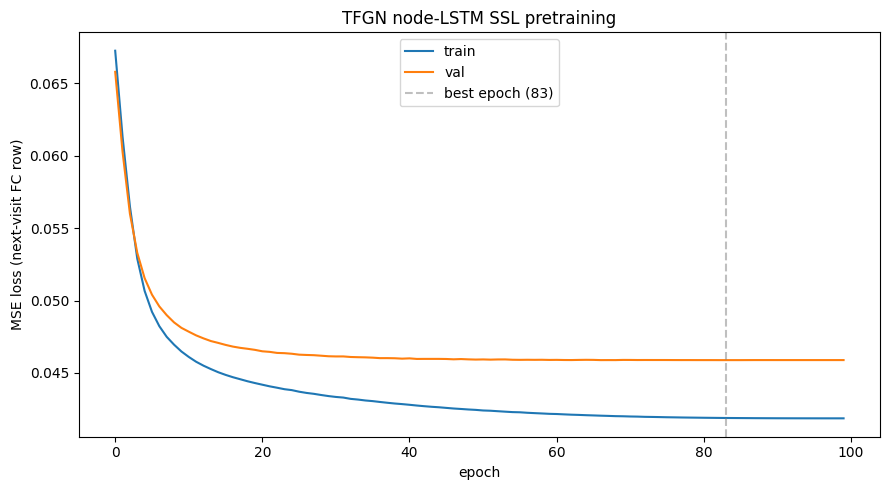

In [16]:
if history.get('train_loss'):
    plt.figure(figsize=(9, 5))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'best epoch ({best_epoch})')
    plt.xlabel('epoch'); plt.ylabel('MSE loss (next-visit FC row)')
    plt.title('TFGN node-LSTM SSL pretraining')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print('No training history to plot (USE_EXISTING=True).')
